#Pobieranie odpowiednich bibliotek

In [ ]:
!pip install opencv-python

In [ ]:
#importy
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

#Funkcja do rozponawania bananów

In [ ]:
def HowIsYourBananaDoing(image_path):
  img = cv2.imread(image_path)
  if img is None:
    return "Nie można wczytać obrazu"

  og_img = img.copy()

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  blurred = cv2.GaussianBlur(gray, (15, 15), 0)
  _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)
  contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if not contours:
        return "Nie wykryto obiektu."

  largest_contour = max(contours, key=cv2.contourArea)

  mask = np.zeros(gray.shape, dtype="uint8")
  cv2.drawContours(mask, [largest_contour], -1, 255, -1)

  hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

  #zakresy kolorów
  lower_green = np.array([33, 10, 10])
  upper_green = np.array([85, 255, 255])

  lower_yellow = np.array([20, 10, 10])
  upper_yellow = np.array([32, 255, 255])

  lower_black = np.array([0, 0, 0])
  upper_black = np.array([255, 255, 70])
  lower_brown = np.array([10, 150, 20])
  upper_brown = np.array([19, 255, 200])

  #definiowanie masek; czarny łączy się z brązowym, ponieważ funkcjonalnie spełniają tę samą rolę
  green_mask = cv2.inRange(hsv_img, lower_green, upper_green)
  green_mask = cv2.bitwise_and(green_mask, mask)

  yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
  yellow_mask = cv2.bitwise_and(yellow_mask, mask)

  black_mask1 = cv2.inRange(hsv_img, lower_black, upper_black)
  black_mask2 = cv2.inRange(hsv_img, lower_brown, upper_brown)
  black_mask = cv2.bitwise_or(black_mask1, black_mask2)
  black_mask = cv2.bitwise_and(black_mask, mask)

  green_pixels = cv2.countNonZero(green_mask)
  yellow_pixels = cv2.countNonZero(yellow_mask)
  black_pixels = cv2.countNonZero(black_mask)

  #status banana
  status = "unknown"
  if green_pixels >= black_pixels and green_pixels >= yellow_pixels:
        status = "niedojrzaly"
        color_text = (0, 255, 0)
  elif yellow_pixels > green_pixels and yellow_pixels > black_pixels:
        status = "dojrzaly"
        color_text = (30, 240, 255)
  elif black_pixels >= yellow_pixels and black_pixels >= green_pixels:
        status = "przejrzaly"
        color_text = (30, 100, 100)

  #wizualizacja obrazów pośrednich

  #HSV
  print("Warstwy HSV na czarno-biało:")
  plt.figure(figsize=(24,12))

  plt.subplot(2,3,1)
  plt.imshow(hsv_img[:,:,0], cmap="gray")
  plt.title("H - Hue")
  plt.axis("off")

  plt.subplot(2,3,2)
  plt.imshow(hsv_img[:,:,1], cmap="gray")
  plt.title("S - Saturation")
  plt.axis("off")

  plt.subplot(2,3,3)
  plt.imshow(hsv_img[:,:,2], cmap="gray")
  plt.title("V - Value")
  plt.axis("off")

  plt.show()

  #wizualzacja maski pixeli
  print("Maski pixeli:")
  plt.figure(figsize=(24,12))

  cv2.imwrite('black_map.jpg', black_mask)

  plt.subplot(1,3,1)
  plt.imshow(cv2.imread('/content/black_map.jpg'))
  plt.title("Czarna maska")
  plt.axis("off")

  cv2.imwrite('green_map.jpg', green_mask)

  plt.subplot(1,3,2)
  plt.imshow(cv2.imread('/content/green_map.jpg'))
  plt.title("Zielona maska")
  plt.axis("off")

  cv2.imwrite('yellow_map.jpg', yellow_mask)

  plt.subplot(1,3,3)
  plt.imshow(cv2.imread('/content/yellow_map.jpg'))
  plt.title("Żółta maska")
  plt.axis("off")

  plt.show()

  #nałożenie ramki i podpisanie wyniku
  x, y, w, h = cv2.boundingRect(largest_contour)
  cv2.rectangle(og_img, (x, y), (x+w, y+h), (255, 0, 0), 2)
  cv2.putText(og_img, status, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color_text, 2)

  print("Początek, HSV i efekt finalny")
  plt.figure(figsize=(24,12))

  plt.subplot(1,3,1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title("Oryginalne zdjęcie")
  plt.axis("off")

  plt.subplot(1,3,2)
  plt.imshow(cv2.cvtColor(hsv_img, cv2.COLOR_BGR2RGB))
  plt.title("Po konwersji z BGR na HSV")
  plt.axis("off")

  plt.subplot(1,3,3)
  plt.imshow(cv2.cvtColor(og_img, cv2.COLOR_BGR2RGB))
  plt.title("Wykrywanie banana + przewidywanie dojrzałości")
  plt.axis("off")

  plt.show()

  #wynik
  print(f"ILOŚĆ PIXELI: zielone: {green_pixels} || żółte: {yellow_pixels} || czarne/brązowe: {black_pixels}")
  print("Program przewiduje, że przesłany banan jest: ", status)


#Jak działa nasz algorytm?

> Wykrywa banana, po czym oddziela go od tła. Następnie tworzy 4 oddzielne maski kolorostyczne (po czym łączy czarną z brązową, więc zostają 3) i zlicza piksele. Jeśli najwięcej jest żółtych, algorytm decyduje, że banan jest dojrzały, itp. itd.



#Wywołanie funkcji

Warstwy HSV na czarno-biało:


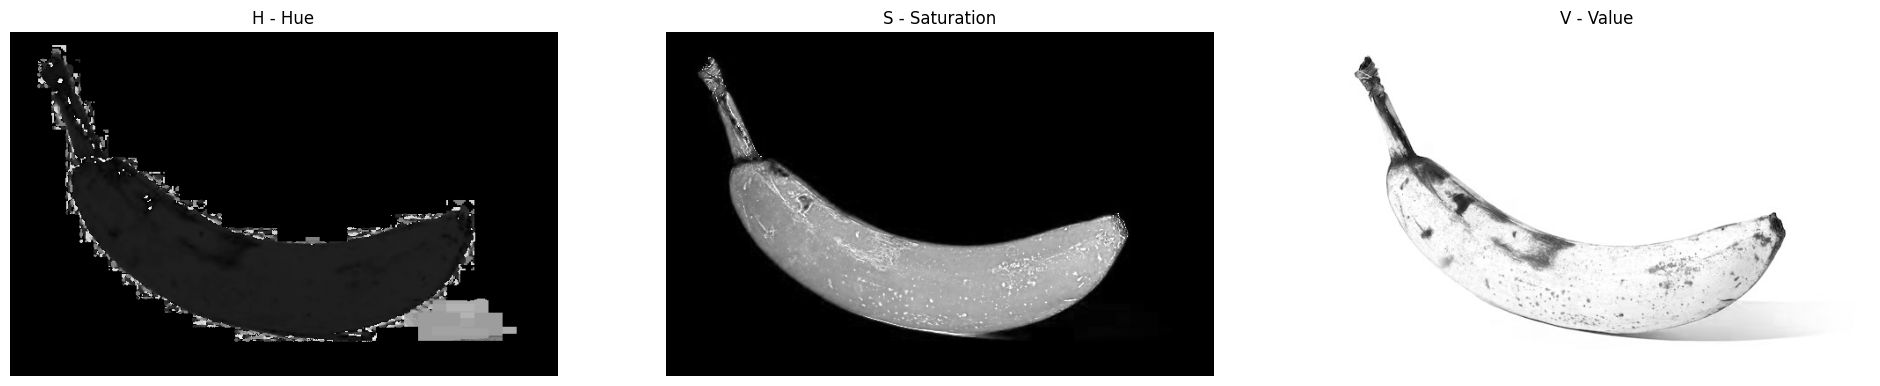

Maski pixeli:


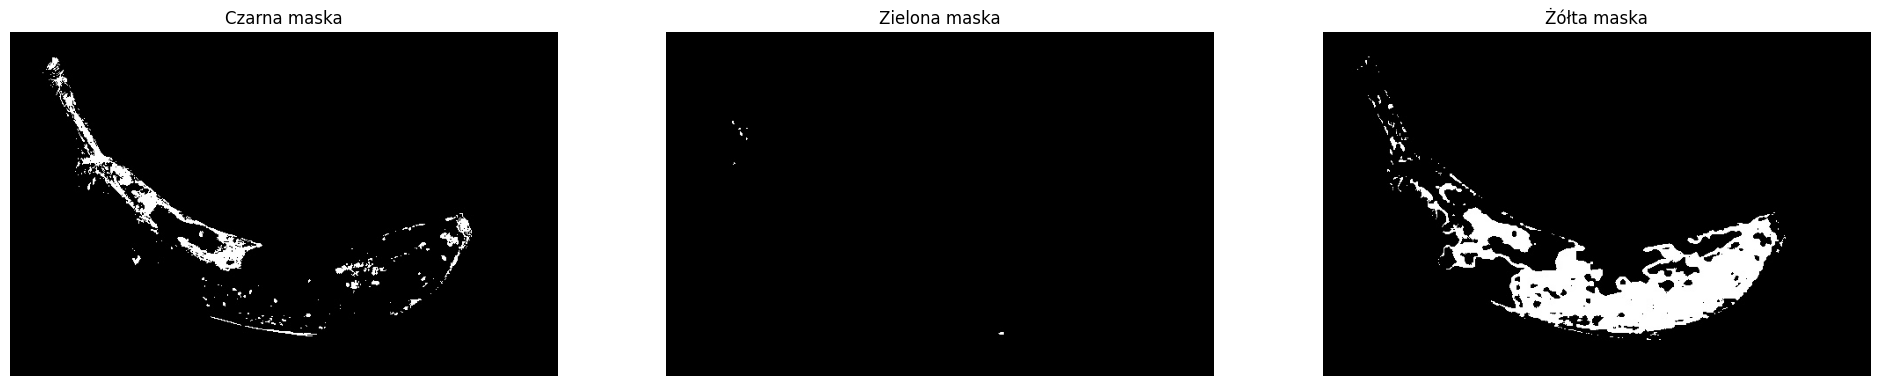

Początek, HSV i efekt finalny


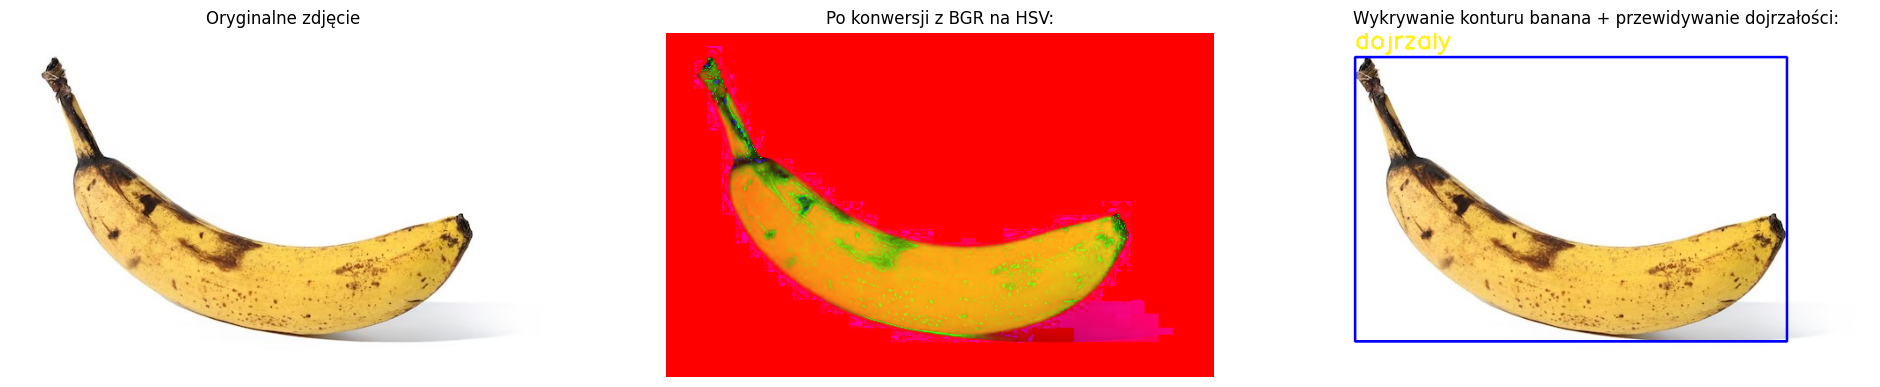

ILOŚĆ PIXELI: zielone: 49 || żółte: 22507 || czarne/brązowe: 6446
Program przewiduje, że przesłany banan jest:  dojrzaly


In [ ]:
HowIsYourBananaDoing('/content/banan.jpg')